Name: Utkarsh Vishwanath Parulekar

Roll No: CS39

Batch: CS03

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Task 1: Environment Setup and Dataset Acquisition

# 1. Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import os # Import os module for file checking

# 2. Define column names
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# 3. Load the dataset
# Keep the pima-indians-diabetes.data file in the same folder as this Python program
file_path = 'pima-indians-diabetes.csv'

# Check if the file exists OR if it exists but is empty; if so, download it.
if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
    print(f"File '{file_path}' not found or is empty. Attempting to download from a public source.")
    # Updated download URL to a working source for the Pima Indians Diabetes dataset
    download_url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
    try:
        get_ipython().system(f'wget -O {file_path} {download_url}')
        print(f"File '{file_path}' downloaded successfully.")
        # After download, immediately check if the file is still empty. If so, raise an error.
        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
            raise FileNotFoundError(f"Downloaded file '{file_path}' is still not found or is empty. Please check the download URL.")
    except Exception as e:
        print(f"Error downloading the file: {e}")
        print(f"Please ensure the file '{file_path}' is uploaded to your Colab environment or provide the correct download URL.")
        # If download fails, we should not proceed to read the file.
        raise FileNotFoundError(f"Could not download or find file: '{file_path}'. Please check the path or ensure the file is present.")

# Verify file size (this block is now redundant due to the check above but kept for explicit output)
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"File '{file_path}' size: {file_size} bytes")
    if file_size == 0:
        print("Warning: The file exists but is empty. Please check the download URL or file source.")
        raise ValueError(f"The file '{file_path}' is empty after download attempt. Cannot load dataset.")

# Explicitly set separator and no header for robust parsing
# Use skiprows=1 to skip the header row that is now present in the downloaded CSV
dataset = pd.read_csv(file_path, names=columns, sep=',', skiprows=1)

# 4. Print first five records
print("First Five Records:")
print(dataset.head())

# 5. Print dataset shape
print("\nDataset Shape:")
print(dataset.shape)

# 6. Print data types of all features
print("\nData Types of All Features:")
print(dataset.dtypes)

# 7. Print descriptive statistics
print("\nDescriptive Statistics:")
print(dataset.describe())

File 'pima-indians-diabetes.csv' size: 23873 bytes
First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types of All Features:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int6

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Absolute Count:
Non-Diabetic (0): 500
Diabetic (1): 268

Percentage:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %


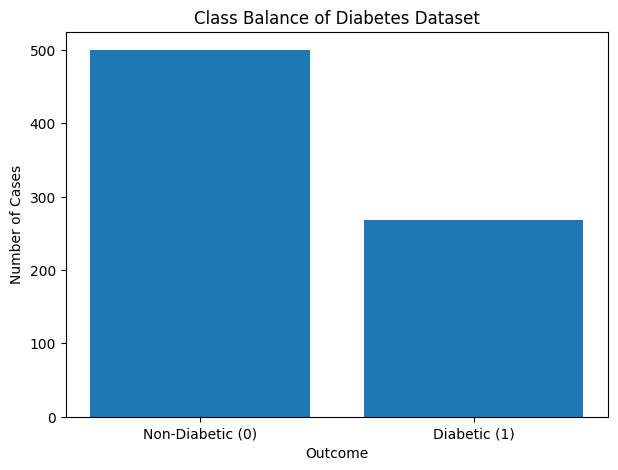

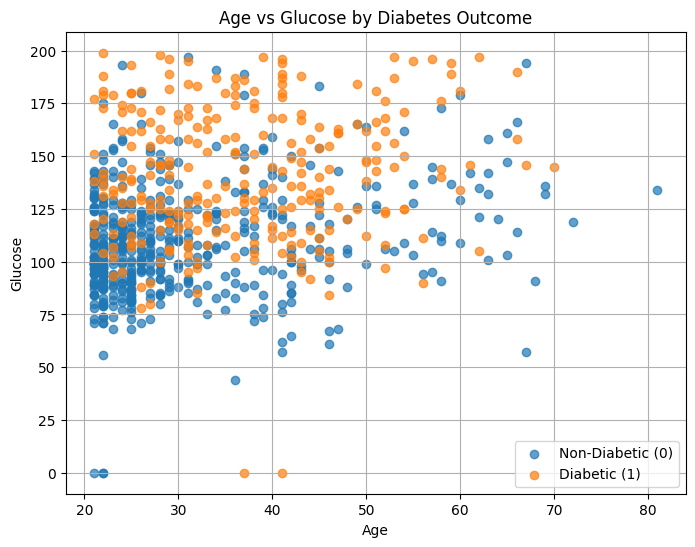


Explanation:
A simple linear decision boundary is insufficient because
diabetic and non-diabetic patients overlap in the Age-Glucose
feature space. Diabetes depends on multiple features such as
Glucose, BMI, Blood Pressure, Insulin, Age and Pregnancies.
Therefore, a single straight line cannot clearly separate
all diabetic and non-diabetic cases.


In [ ]:
# Task 2: Exploratory Data Analysis (EDA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# ---------------------------------------------------------
# 1. Class Balance
# ---------------------------------------------------------

# Calculate absolute count
count = dataset['Outcome'].value_counts().sort_index()

# Calculate percentage
percentage = dataset['Outcome'].value_counts(
    normalize=True
).sort_index() * 100

print("Absolute Count:")
print("Non-Diabetic (0):", count[0])
print("Diabetic (1):", count[1])

print("\nPercentage:")
print("Non-Diabetic (0):", round(percentage[0], 2), "%")
print("Diabetic (1):", round(percentage[1], 2), "%")


# Bar Chart
plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    [count[0], count[1]]
)

plt.xlabel("Outcome")
plt.ylabel("Number of Cases")
plt.title("Class Balance of Diabetes Dataset")

plt.show()


# ---------------------------------------------------------
# 2. Scatter Plot: Age vs Glucose
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

# Non-diabetic patients
non_diabetic = dataset[dataset['Outcome'] == 0]

# Diabetic patients
diabetic = dataset[dataset['Outcome'] == 1]

plt.scatter(
    non_diabetic['Age'],
    non_diabetic['Glucose'],
    label='Non-Diabetic (0)',
    alpha=0.7
)

plt.scatter(
    diabetic['Age'],
    diabetic['Glucose'],
    label='Diabetic (1)',
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose by Diabetes Outcome")
plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 3. Explanation
# ---------------------------------------------------------

print("\nExplanation:")
print("A simple linear decision boundary is insufficient because")
print("diabetic and non-diabetic patients overlap in the Age-Glucose")
print("feature space. Diabetes depends on multiple features such as")
print("Glucose, BMI, Blood Pressure, Insulin, Age and Pregnancies.")
print("Therefore, a single straight line cannot clearly separate")
print("all diabetic and non-diabetic cases.")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# Task 3: Preprocessing and Handling Missing Values

import numpy as np
import pandas as pd

# Features where 0 is physically impossible
invalid_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# ---------------------------------------------------------
# 1. Identify invalid zero values
# ---------------------------------------------------------

print("Number of invalid 0 values before replacement:")

for feature in invalid_features:
    print(feature, ":", (dataset[feature] == 0).sum())


# ---------------------------------------------------------
# 2. Replace 0 values with NaN
# ---------------------------------------------------------

dataset[invalid_features] = dataset[invalid_features].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")

print(dataset[invalid_features].isnull().sum())


# ---------------------------------------------------------
# 3. Impute missing values using median
# ---------------------------------------------------------

for feature in invalid_features:
    dataset[feature] = dataset[feature].fillna(dataset[feature].median())


# ---------------------------------------------------------
# 4. Check whether missing values remain
# ---------------------------------------------------------

print("\nMissing values after median imputation:")

print(dataset[invalid_features].isnull().sum())


# ---------------------------------------------------------
# 5. Display the cleaned dataset
# ---------------------------------------------------------

print("\nFirst five records after preprocessing:")
print(dataset.head())

Number of invalid 0 values before replacement:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing 0 with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1     

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Separate Features (X) and Target (y)
# ---------------------------------------------------------

# First 8 columns are features
X = dataset.iloc[:, :8]

# 9th column is the target
y = dataset.iloc[:, 8]


# Display shapes
print("Feature Matrix (X) Shape:", X.shape)
print("Target Vector (y) Shape:", y.shape)


# ---------------------------------------------------------
# 2. Split Dataset into Training and Testing Data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# 3. Display the shapes
# ---------------------------------------------------------

print("\nTraining Data:")
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("\nTesting Data:")
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)


# ---------------------------------------------------------
# 4. Check Class Proportions
# ---------------------------------------------------------

print("\nOriginal Class Proportion:")
print(y.value_counts(normalize=True))

print("\nTraining Class Proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Proportion:")
print(y_test.value_counts(normalize=True))

Feature Matrix (X) Shape: (768, 8)
Target Vector (y) Shape: (768,)

Training Data:
X_train Shape: (614, 8)
y_train Shape: (614,)

Testing Data:
X_test Shape: (154, 8)
y_test Shape: (154,)

Original Class Proportion:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training Class Proportion:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Class Proportion:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# Task 5: Custom Bootstrap Sampling Function

import numpy as np

# ---------------------------------------------------------
# 1. Custom Bootstrap Sampling Function
# ---------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        sample_indices : Indices selected for bootstrap sample
    """

    # Number of samples in training data
    N = len(X)

    # Generate random indices with replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[sample_indices].copy()
    y_bootstrap = y.iloc[sample_indices].copy()

    return X_bootstrap, y_bootstrap, sample_indices


# ---------------------------------------------------------
# 2. Generate Bootstrap Sample
# ---------------------------------------------------------

# Set seed for reproducible results
np.random.seed(42)

X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# ---------------------------------------------------------
# 3. Display Bootstrap Sample Size
# ---------------------------------------------------------

print("Original Training Set Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))

print("\nX Bootstrap Shape:", X_bootstrap.shape)
print("y Bootstrap Shape:", y_bootstrap.shape)


# ---------------------------------------------------------
# 4. Check for Duplicate Indices
# ---------------------------------------------------------

unique_indices, counts = np.unique(
    sample_indices,
    return_counts=True
)

duplicate_indices = unique_indices[counts > 1]

print("\nDuplicated Original Indices:")
print(duplicate_indices)

print("\nNumber of duplicated indices:", len(duplicate_indices))


# ---------------------------------------------------------
# 5. Find Out-of-Bag (OOB) Samples
# ---------------------------------------------------------

all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    np.unique(sample_indices)
)

print("\nOut-of-Bag (OOB) Indices:")
print(oob_indices)

print("\nNumber of OOB samples:", len(oob_indices))


# ---------------------------------------------------------
# 6. Display OOB Samples
# ---------------------------------------------------------

X_oob = X_train.iloc[oob_indices]
y_oob = y_train.iloc[oob_indices]

print("\nOOB Feature Matrix Shape:", X_oob.shape)
print("OOB Target Vector Shape:", y_oob.shape)

Original Training Set Size: 614
Bootstrap Sample Size: 614

X Bootstrap Shape: (614, 8)
y Bootstrap Shape: (614,)

Duplicated Original Indices:
[  1   4   8  11  14  20  21  27  32  34  35  36  38  40  46  52  53  57
  62  64  68  75  80  85  89  91  95  98  99 102 103 105 112 116 119 121
 130 134 142 143 150 159 160 162 166 167 172 176 189 190 191 195 200 202
 214 216 217 219 222 224 226 229 230 232 241 246 251 252 253 255 258 267
 270 276 279 282 284 288 301 304 313 315 322 330 337 339 341 343 345 347
 348 364 366 368 372 373 379 384 385 386 387 389 391 392 395 396 397 400
 401 402 406 407 414 419 421 441 444 452 454 455 459 460 461 470 471 472
 473 474 475 476 484 489 491 492 496 498 502 504 505 509 510 511 512 515
 517 524 546 550 555 562 563 564 565 569 571 573 574 600 606 607 608 609
 611 612]

Number of duplicated indices: 164

Out-of-Bag (OOB) Indices:
[  2   3   5   6  10  12  23  25  29  30  31  33  39  43  44  49  51  54
  55  56  59  60  63  65  66  67  70  72  76  77  78  

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Task 6: Growing the Ensemble of Base Classifiers

import numpy as np
from sklearn.tree import DecisionTreeClassifier

# ---------------------------------------------------------
# 1. Initialize Ensemble
# ---------------------------------------------------------

# Number of bootstrap iterations
B = 50

# Empty list to store trained decision trees
ensemble = []


# ---------------------------------------------------------
# 2. Train B Decision Trees
# ---------------------------------------------------------

for b in range(B):

    # Generate a new bootstrap sample
    X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model
    model.fit(X_bootstrap, y_bootstrap)

    # Add the trained model to the ensemble
    ensemble.append(model)


# ---------------------------------------------------------
# 3. Verify Ensemble
# ---------------------------------------------------------

print("Number of Decision Trees in Ensemble:", len(ensemble))

print("\nEnsemble created successfully!")

# Check the first tree
print("\nFirst Decision Tree:")
print(ensemble[0])

Number of Decision Trees in Ensemble: 50

Ensemble created successfully!

First Decision Tree:
DecisionTreeClassifier(random_state=0)


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# Task 7: Implementing Aggregation (Majority Voting) from Scratch

import numpy as np

# ---------------------------------------------------------
# 1. Custom Bagging Prediction Function
# ---------------------------------------------------------

def custom_bagging_predict(ensemble, X_test):

    # Store predictions of all decision trees
    all_predictions = []

    # Get prediction from each tree
    for model in ensemble:
        prediction = model.predict(X_test)
        all_predictions.append(prediction)

    # Convert predictions to NumPy array
    # Shape: (number_of_trees, number_of_test_samples)
    all_predictions = np.array(all_predictions)

    # Store final majority-voted predictions
    final_predictions = []

    # Perform majority voting for each test sample
    for i in range(X_test.shape[0]):

        # Get predictions from all trees for the current sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_class_0 = np.sum(votes == 0)
        count_class_1 = np.sum(votes == 1)

        # Select class with the highest number of votes
        if count_class_1 > count_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Convert final predictions to NumPy array
    return np.array(final_predictions)


# ---------------------------------------------------------
# 2. Generate Final Predictions
# ---------------------------------------------------------

y_pred = custom_bagging_predict(ensemble, X_test)


# ---------------------------------------------------------
# 3. Display Results
# ---------------------------------------------------------

print("Final Majority Voting Predictions:")
print(y_pred)

print("\nNumber of Test Samples:", len(y_pred))

print("Prediction Shape:", y_pred.shape)

print("\nUnique Predicted Classes:")
print(np.unique(y_pred))

Final Majority Voting Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]

Number of Test Samples: 154
Prediction Shape: (154,)

Unique Predicted Classes:
[0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Confusion Matrix - Single Decision Tree:
[[79 21]
 [28 26]]

Confusion Matrix - Bagging:
[[86 14]
 [26 28]]

Performance Comparison:
----------------------------------------------------------------------
Metric          Single Tree          Bagging             
----------------------------------------------------------------------
Accuracy        0.6818               0.7403              
Precision       0.5532               0.6667              
Recall          0.4815               0.5185              
F1-Score        0.5149               0.5833              
----------------------------------------------------------------------


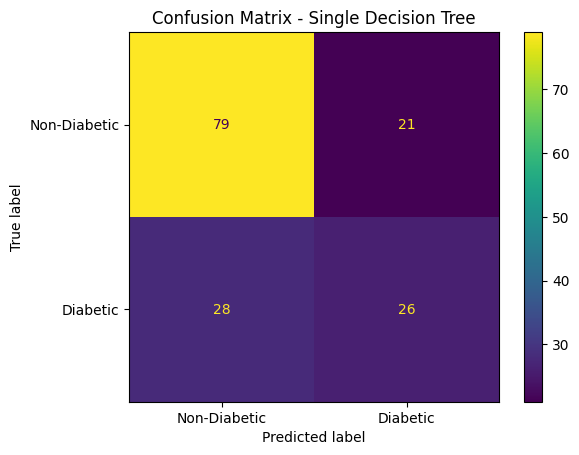

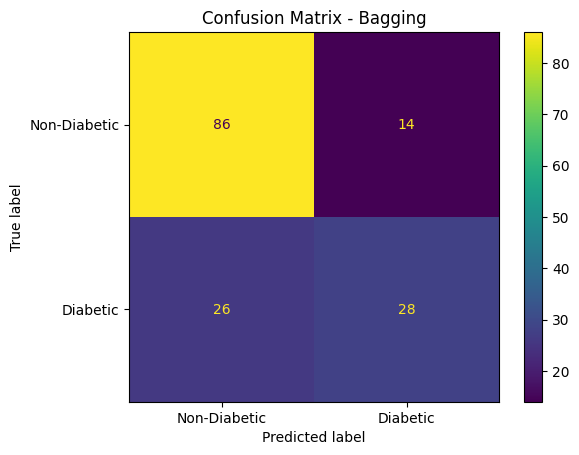

In [ ]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# ---------------------------------------------------------
# 1. Train a Single Fully-Grown Decision Tree
# ---------------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on original, non-resampled training data
single_tree.fit(X_train, y_train)


# ---------------------------------------------------------
# 2. Make Predictions
# ---------------------------------------------------------

# Prediction using single decision tree
y_pred_single = single_tree.predict(X_test)

# Prediction using custom Bagging classifier
y_pred_bagging = custom_bagging_predict(ensemble, X_test)


# ---------------------------------------------------------
# 3. Confusion Matrices
# ---------------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Bagging:")
print(cm_bagging)


# ---------------------------------------------------------
# 4. Calculate Performance Metrics
# ---------------------------------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(y_test, y_pred_single, zero_division=0)
recall_single = recall_score(y_test, y_pred_single, zero_division=0)
f1_single = f1_score(y_test, y_pred_single, zero_division=0)

# Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging, zero_division=0)
recall_bagging = recall_score(y_test, y_pred_bagging, zero_division=0)
f1_bagging = f1_score(y_test, y_pred_bagging, zero_division=0)


# ---------------------------------------------------------
# 5. Print Performance Comparison
# ---------------------------------------------------------

print("\nPerformance Comparison:")
print("-" * 70)

print(f"{'Metric':<15} {'Single Tree':<20} {'Bagging':<20}")
print("-" * 70)

print(f"{'Accuracy':<15} {accuracy_single:<20.4f} {accuracy_bagging:<20.4f}")
print(f"{'Precision':<15} {precision_single:<20.4f} {precision_bagging:<20.4f}")
print(f"{'Recall':<15} {recall_single:<20.4f} {recall_bagging:<20.4f}")
print(f"{'F1-Score':<15} {f1_single:<20.4f} {f1_bagging:<20.4f}")

print("-" * 70)


# ---------------------------------------------------------
# 6. Plot Confusion Matrix - Single Tree
# ---------------------------------------------------------

disp_single = ConfusionMatrixDisplay(
    confusion_matrix=cm_single,
    display_labels=['Non-Diabetic', 'Diabetic']
)

disp_single.plot()
plt.title("Confusion Matrix - Single Decision Tree")
plt.show()


# ---------------------------------------------------------
# 7. Plot Confusion Matrix - Bagging
# ---------------------------------------------------------

disp_bagging = ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=['Non-Diabetic', 'Diabetic']
)

disp_bagging.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC Results
----------------------------------------
Single Decision Tree AUC: 0.6357
Custom Bagging AUC: 0.81


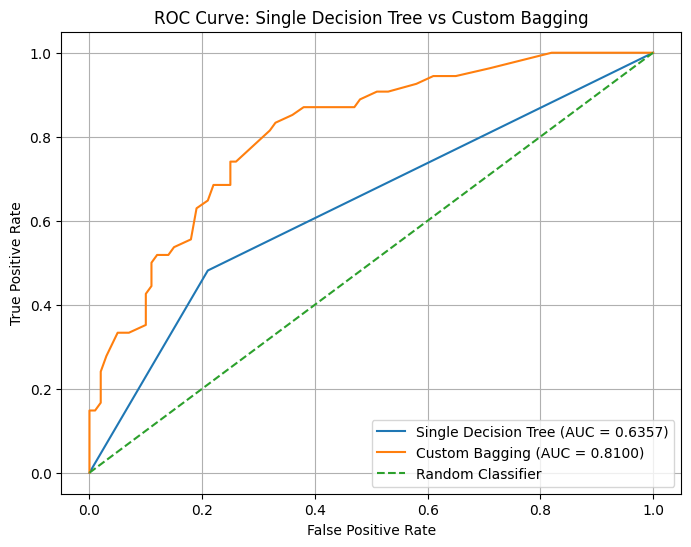


AUC Comparison:
Bagging has a higher AUC than the Single Decision Tree.

AUC Difference: 0.1743


In [ ]:
# Task 9: ROC-AUC Analysis and Curve Visualization

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score


# ---------------------------------------------------------
# 1. Probability Prediction for Single Decision Tree
# ---------------------------------------------------------

# Get probability of class 1 (Diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# 2. Probability Prediction for Custom Bagging
# ---------------------------------------------------------

# Store probability predictions from all decision trees
all_probabilities = []

for model in ensemble:

    # Get probability of class 1
    probability = model.predict_proba(X_test)[:, 1]

    # Store the probability
    all_probabilities.append(probability)


# Convert to NumPy array
all_probabilities = np.array(all_probabilities)

# Average probabilities across all 50 trees
y_prob_bagging = np.mean(all_probabilities, axis=0)


# ---------------------------------------------------------
# 3. Calculate ROC Curve
# ---------------------------------------------------------

# Single Decision Tree ROC
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

# Bagging ROC
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ---------------------------------------------------------
# 4. Calculate AUC
# ---------------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# ---------------------------------------------------------
# 5. Print AUC Values
# ---------------------------------------------------------

print("ROC-AUC Results")
print("-" * 40)

print("Single Decision Tree AUC:",
      round(auc_single, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))


# ---------------------------------------------------------
# 6. Plot ROC Curves
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.4f})"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")

plt.legend()
plt.grid(True)

plt.show()


# ---------------------------------------------------------
# 7. Compare AUC
# ---------------------------------------------------------

print("\nAUC Comparison:")

if auc_bagging > auc_single:
    print("Bagging has a higher AUC than the Single Decision Tree.")
elif auc_bagging < auc_single:
    print("Single Decision Tree has a higher AUC than Bagging.")
else:
    print("Both models have the same AUC.")

print("\nAUC Difference:",
      round(auc_bagging - auc_single, 4))

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# ---------------------------------------------------------
# 1. Create Scikit-Learn Bagging Classifier
# ---------------------------------------------------------

base_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)


# ---------------------------------------------------------
# 2. Train the Bagging Classifier
# ---------------------------------------------------------

bagging_model.fit(X_train, y_train)


# ---------------------------------------------------------
# 3. Make Predictions
# ---------------------------------------------------------

# Scikit-Learn Bagging prediction
y_pred_sklearn = bagging_model.predict(X_test)

# Custom Bagging prediction from Task 7
y_pred_custom = custom_bagging_predict(
    ensemble,
    X_test
)


# ---------------------------------------------------------
# 4. Calculate Accuracy
# ---------------------------------------------------------

accuracy_custom = accuracy_score(
    y_test,
    y_pred_custom
)

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# ---------------------------------------------------------
# 5. Calculate Confusion Matrices
# ---------------------------------------------------------

cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# ---------------------------------------------------------
# 6. Display Results
# ---------------------------------------------------------

print("=" * 60)
print("CUSTOM BAGGING vs SCIKIT-LEARN BAGGING")
print("=" * 60)

print("\nCustom Bagging Accuracy:")
print(round(accuracy_custom, 4))

print("\nScikit-Learn Bagging Accuracy:")
print(round(accuracy_sklearn, 4))


print("\n" + "-" * 60)
print("Custom Bagging Confusion Matrix:")
print("-" * 60)
print(cm_custom)


print("\n" + "-" * 60)
print("Scikit-Learn Bagging Confusion Matrix:")
print("-" * 60)
print(cm_sklearn)


# ---------------------------------------------------------
# 7. Accuracy Comparison
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("ACCURACY COMPARISON")
print("=" * 60)

print(f"Custom Bagging      : {accuracy_custom:.4f}")
print(f"Scikit-Learn Bagging: {accuracy_sklearn:.4f}")
print(f"Difference          : {abs(accuracy_custom - accuracy_sklearn):.4f}")

CUSTOM BAGGING vs SCIKIT-LEARN BAGGING

Custom Bagging Accuracy:
0.7403

Scikit-Learn Bagging Accuracy:
0.7338

------------------------------------------------------------
Custom Bagging Confusion Matrix:
------------------------------------------------------------
[[86 14]
 [26 28]]

------------------------------------------------------------
Scikit-Learn Bagging Confusion Matrix:
------------------------------------------------------------
[[85 15]
 [26 28]]

ACCURACY COMPARISON
Custom Bagging      : 0.7403
Scikit-Learn Bagging: 0.7338
Difference          : 0.0065


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?